![WhatsApp Image 2026-05-12 at 10.00.56 PM.jpeg](<attachment:WhatsApp Image 2026-05-12 at 10.00.56 PM.jpeg>)
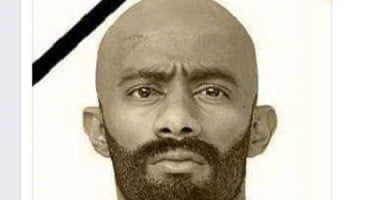

🔆 GPU

In [ ]:
import torch
torch.autograd.set_detect_anomaly(True)

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
print(torch.cuda.is_available())

True


In [5]:
x = torch.rand(2, 3).to("cuda")
print(x)

tensor([[8.5582e-01, 7.5308e-01, 6.7139e-04],
        [2.2763e-01, 6.6574e-01, 8.3077e-01]], device='cuda:0')


______________________________________________________________________________________________________________
LIBRARIES
______________________________________________________________________________________________________________

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#_________________________________________________________
import random
import os
import cv2
from collections import Counter
from PIL import Image , ImageFile
#_________________________________________________________
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import shuffle
#_________________________________________________________
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img , ImageDataGenerator
#_________________________________________________________
from glob import glob
from tqdm import tqdm
import albumentations as A

#OPTIMIZATION
#_________________________________________________________
from tensorflow.keras.optimizers import AdamW
from pyswarm import pso

______________________________________________________________________________________________________________
INFORMATION AND VISUALIZATION TRAIN & TEST & VAL
______________________________________________________________________________________________________________

TRAIN DATA
______________________________________________________________________________________________________________

In [28]:
train_path = r'M:\جامعة ترم 2 (3)\ieee\train'

print("Content:", os.listdir(train_path))

Content: ['fractured', 'not fractured']


In [29]:
fractured_tr = os.path.join(train_path, 'fractured')
not_fractured_tr = os.path.join(train_path, 'not Fractured')

In [30]:
fractured_file_tr = [os.path.join(fractured_tr, f) for f in os.listdir(fractured_tr)]
not_fractured_file_tr = [os.path.join(not_fractured_tr, f) for f in os.listdir(not_fractured_tr)]

print("Num of fractured img->", len(fractured_file_tr))
print("Num of Non-Fractured img->", len(not_fractured_file_tr))
print("Total Num of img->", len(fractured_file_tr) + len(not_fractured_file_tr))

Num of fractured img-> 4606
Num of Non-Fractured img-> 4640
Total Num of img-> 9246


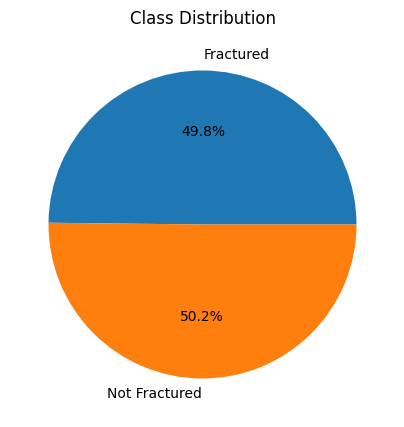

In [31]:
labels = ["Fractured", "Not Fractured"]
values = [len(fractured_file_tr), len(not_fractured_file_tr)]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

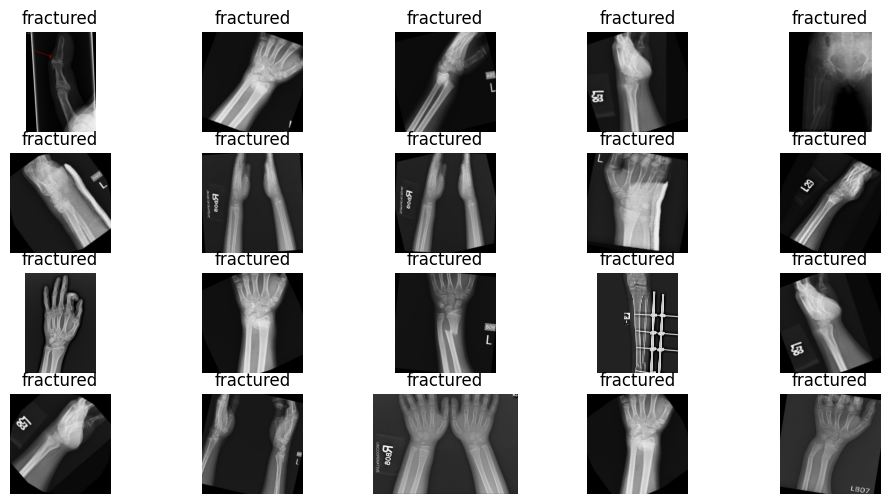

In [32]:
folder = r"M:\جامعة ترم 2 (3)\ieee\train\fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("fractured")

plt.show()

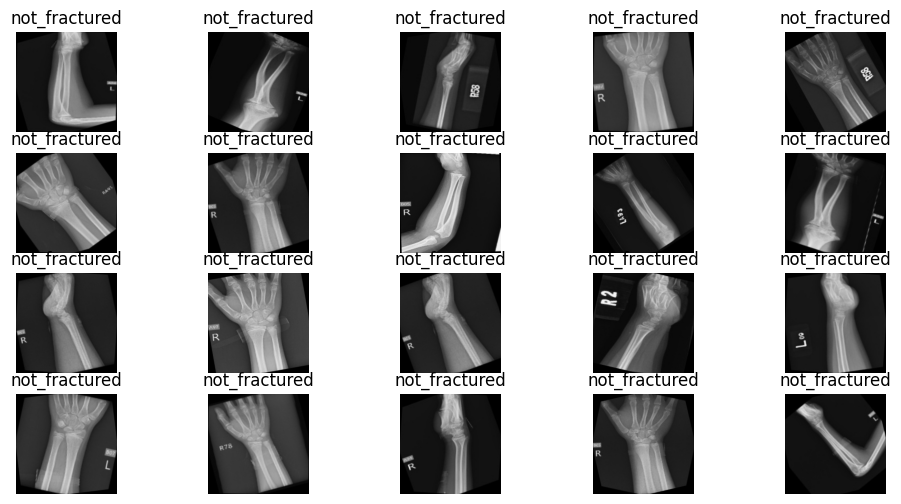

In [33]:
folder = r"M:\جامعة ترم 2 (3)\ieee\train\not fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("not_fractured")

plt.show()

In [34]:
all_files = fractured_file_tr + not_fractured_file_tr

sizes = []

for f in all_files[:500]: 
    try:
        img = Image.open(f)
        sizes.append(img.size)
    except:
        continue

print("Number of images checked:", len(sizes))
print("Unique sizes:", len(set(sizes)))

common_sizes = Counter(sizes).most_common(10)
print("\nTop image sizes:")
for s, c in common_sizes:
    print(s, "->", c)

Number of images checked: 500
Unique sizes: 165

Top image sizes:
(224, 224) -> 257
(285, 380) -> 6
(1517, 2021) -> 4
(1698, 1917) -> 4
(834, 1514) -> 4
(846, 1498) -> 4
(1946, 1557) -> 4
(800, 1093) -> 4
(484, 734) -> 4
(2328, 2928) -> 3


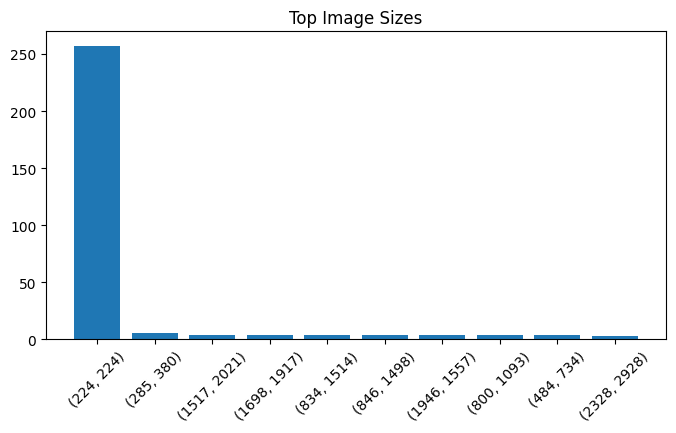

In [35]:
top = Counter(sizes).most_common(10)

labels = [str(x[0]) for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Image Sizes")
plt.show()

In [36]:
channels = Counter()

for f in all_files[:500]:
    try:
        img = Image.open(f)

        if img.mode == "RGB":
            channels["RGB"] += 1
        elif img.mode == "L":
            channels["Grayscale"] += 1
        else:
            channels["Other"] += 1

    except:
        continue

print(channels)

Counter({'RGB': 437, 'Grayscale': 54, 'Other': 9})


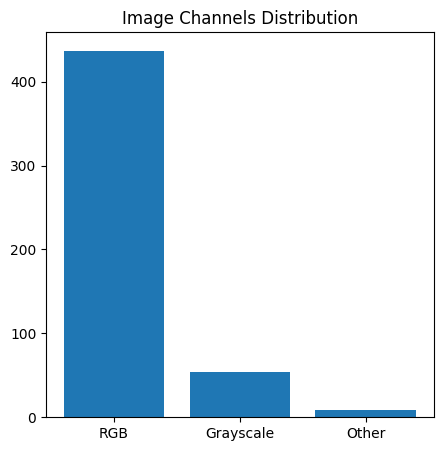

In [37]:
plt.figure(figsize=(5,5))
plt.bar(channels.keys(), channels.values())
plt.title("Image Channels Distribution")
plt.show()

In [38]:
broken = []

for f in all_files:
    try:
        Image.open(f).verify()
    except:
        broken.append(f)

print("Broken images:", len(broken))

Broken images: 0


______________________________________________________________________________________________________________
TEST DATA
______________________________________________________________________________________________________________

In [39]:
test_path = r'M:\جامعة ترم 2 (3)\ieee\test'

print("Content:", os.listdir(test_path))

Content: ['fractured', 'not fractured']


In [40]:
fractured_ts = os.path.join(test_path, 'fractured')
not_fractured_ts = os.path.join(test_path, 'not Fractured')

In [41]:
fractured_file_ts = [os.path.join(fractured_ts, f) for f in os.listdir(fractured_ts)]
not_fractured_file_ts = [os.path.join(not_fractured_ts, f) for f in os.listdir(not_fractured_ts)]

print("Num of fractured img->", len(fractured_file_ts))
print("Num of Non-Fractured img->", len(not_fractured_file_ts))
print("Total Num of img->", len(fractured_file_ts) + len(not_fractured_file_ts))

Num of fractured img-> 238
Num of Non-Fractured img-> 268
Total Num of img-> 506


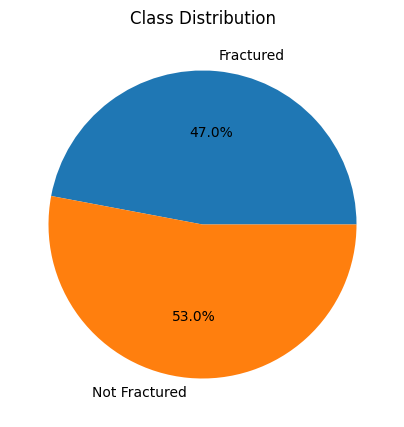

In [42]:
import matplotlib.pyplot as plt

labels = ["Fractured", "Not Fractured"]
values = [len(fractured_file_ts), len(not_fractured_file_ts)]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

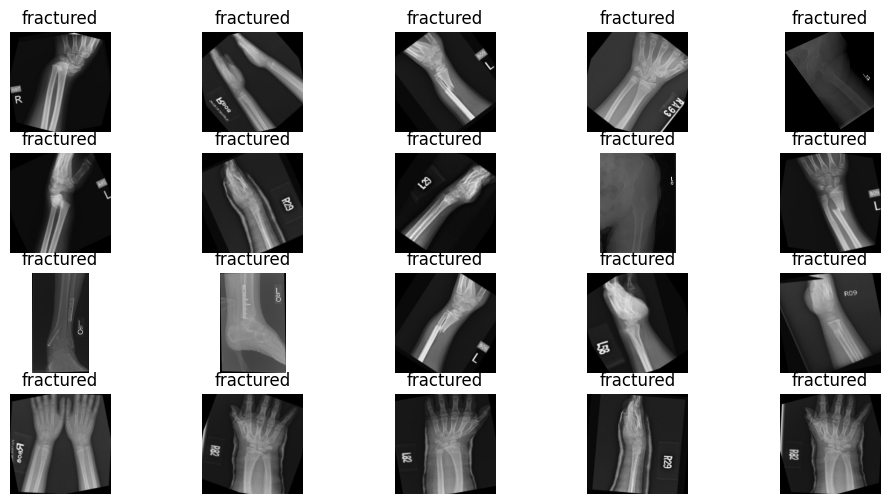

In [43]:
folder = r"M:\جامعة ترم 2 (3)\ieee\test\fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("fractured")

plt.show()

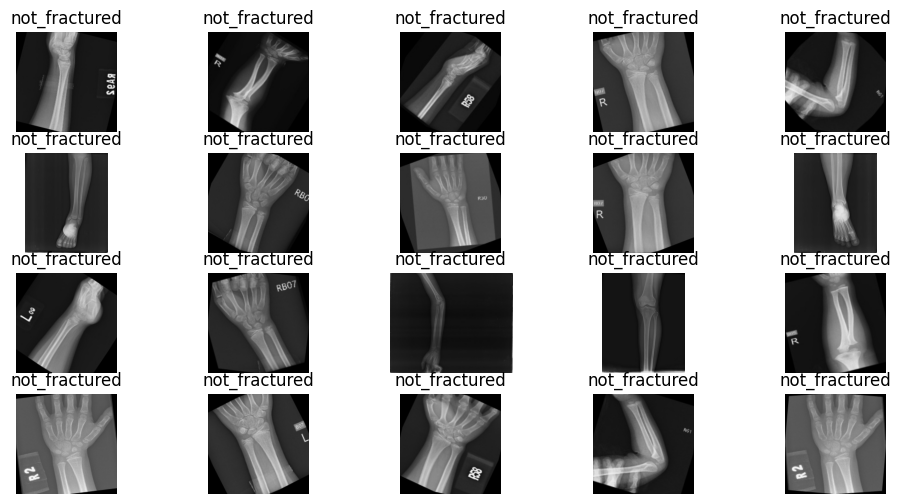

In [44]:
folder = r"M:\جامعة ترم 2 (3)\ieee\test\not fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("not_fractured")

plt.show()

In [45]:
all_files_ts = fractured_file_ts + not_fractured_file_ts

sizes_ts = []

for f in all_files_ts[:500]:
    try:
        img = Image.open(f)
        sizes_ts.append(img.size)  
    except:
        continue

print("Number of images checked:", len(sizes_ts))
print("Unique sizes:", len(set(sizes_ts)))

common_sizes = Counter(sizes_ts).most_common(10)
print("\nTop image sizes:")
for s, c in common_sizes:
    print(s, "->", c)

Number of images checked: 500
Unique sizes: 26

Top image sizes:
(224, 224) -> 392
(2304, 2880) -> 24
(373, 454) -> 16
(2320, 2920) -> 8
(1946, 1557) -> 7
(846, 1498) -> 6
(834, 1514) -> 5
(2328, 2928) -> 4
(1179, 1493) -> 4
(1517, 2021) -> 4


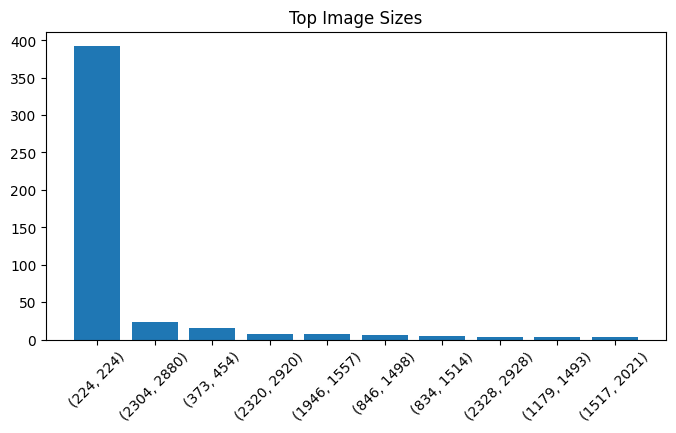

In [46]:
top = Counter(sizes_ts).most_common(10)

labels = [str(x[0]) for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Image Sizes")
plt.show()

In [47]:
channels_ts = Counter()

for f in all_files_ts[:500]:
    try:
        img = Image.open(f)

        if img.mode == "RGB":
            channels_ts["RGB"] += 1
        elif img.mode == "L":
            channels_ts["Grayscale"] += 1
        else:
            channels_ts["Other"] += 1

    except:
        continue

print(channels_ts)

Counter({'RGB': 411, 'Grayscale': 89})


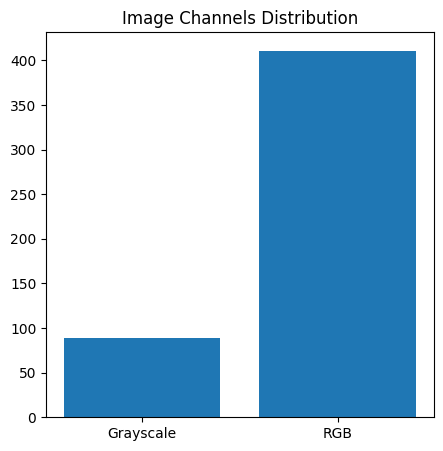

In [48]:
plt.figure(figsize=(5,5))
plt.bar(channels_ts.keys(), channels_ts.values())
plt.title("Image Channels Distribution")
plt.show()

In [49]:
broken_ts = []

for f in all_files_ts:
    try:
        Image.open(f).verify()
    except:
        broken_ts.append(f)

print("Broken images:", len(broken_ts))

Broken images: 0


______________________________________________________________________________________________________________
VAL DATA
______________________________________________________________________________________________________________

In [50]:
val_path = r'M:\جامعة ترم 2 (3)\ieee\val'

print("Content:", os.listdir(val_path))

Content: ['fractured', 'not fractured']


In [51]:
fractured_val = os.path.join(val_path, 'fractured')
not_fractured_val = os.path.join(val_path, 'not Fractured')

In [52]:
fractured_file_val = [os.path.join(fractured_val, f) for f in os.listdir(fractured_val)]
not_fractured_file_val = [os.path.join(not_fractured_val, f) for f in os.listdir(not_fractured_val)]

print("Num of fractured img->", len(fractured_file_val))
print("Num of Non-Fractured img->", len(not_fractured_file_val))
print("Total Num of img->", len(fractured_file_val) + len(not_fractured_file_val))

Num of fractured img-> 337
Num of Non-Fractured img-> 492
Total Num of img-> 829


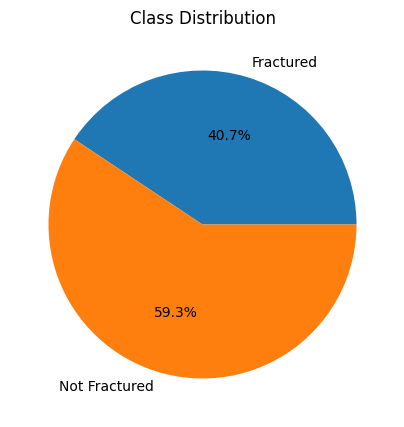

In [53]:
import matplotlib.pyplot as plt

labels = ["Fractured", "Not Fractured"]
values = [len(fractured_file_val), len(not_fractured_file_val)]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

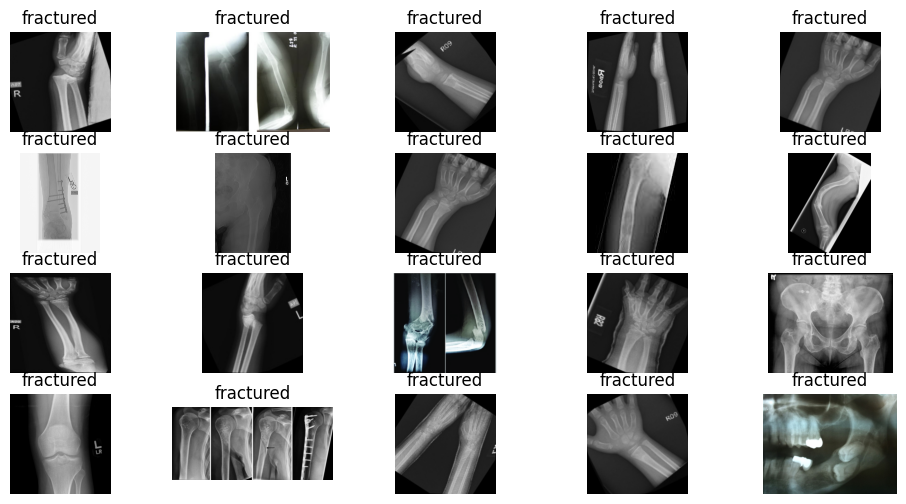

In [54]:
folder = r"M:\جامعة ترم 2 (3)\ieee\val\fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("fractured")

plt.show()

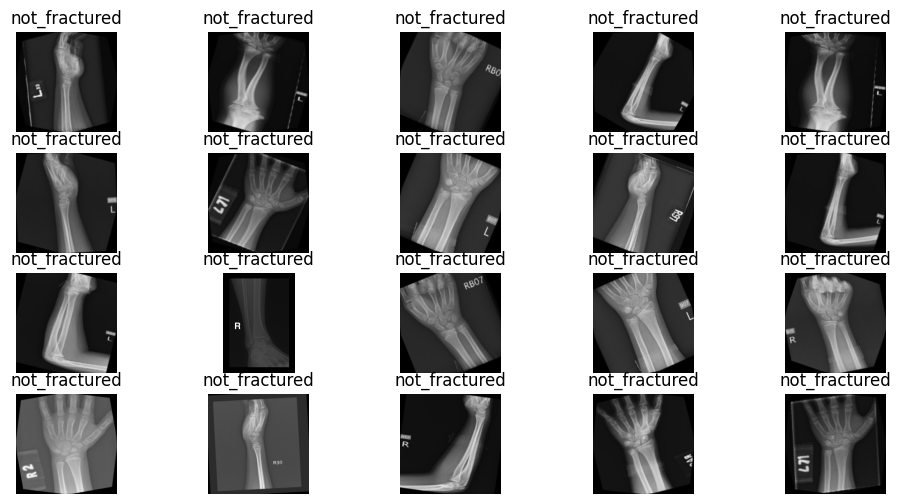

In [55]:
folder = r"M:\جامعة ترم 2 (3)\ieee\val\not fractured"

files =random.sample([f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))], k=20)

plt.figure(figsize=(12,6))

for i, f in enumerate(files):
    path = os.path.join(folder, f)

    try:
        img = Image.open(path).convert("RGB")
    except:
        print("i can't read :", path)
        continue

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("not_fractured")

plt.show()

In [56]:
all_files_val = fractured_file_val + not_fractured_file_val

sizes_val = []

for f in all_files_val[:500]:
    try:
        img = Image.open(f)
        sizes_val.append(img.size) 
    except:
        continue

print("Number of images checked:", len(sizes_val))
print("Unique sizes:", len(set(sizes_val)))

common_sizes = Counter(sizes_val).most_common(10)
print("\nTop image sizes:")
for s, c in common_sizes:
    print(s, "->", c)

Number of images checked: 500
Unique sizes: 112

Top image sizes:
(224, 224) -> 315
(373, 454) -> 21
(100, 100) -> 20
(2304, 2880) -> 7
(2320, 2920) -> 5
(2328, 2928) -> 4
(1517, 2021) -> 4
(1698, 1917) -> 4
(834, 1514) -> 4
(846, 1498) -> 4


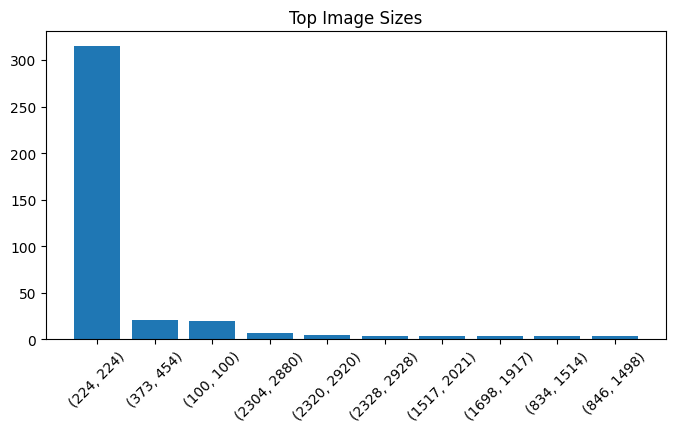

In [57]:
top = Counter(sizes_val).most_common(10)

labels = [str(x[0]) for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Image Sizes")
plt.show()

In [58]:
channels_val = Counter()

for f in all_files_val[:500]:
    try:
        img = Image.open(f)

        if img.mode == "RGB":
            channels_val["RGB"] += 1
        elif img.mode == "L":
            channels_val["Grayscale"] += 1
        else:
            channels_val["Other"] += 1

    except:
        continue

print(channels_val)

Counter({'RGB': 408, 'Grayscale': 82, 'Other': 10})


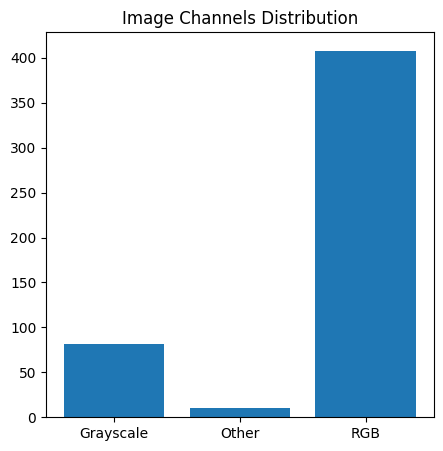

In [59]:
plt.figure(figsize=(5,5))
plt.bar(channels_val.keys(), channels_val.values())
plt.title("Image Channels Distribution")
plt.show()

In [60]:
broken_val = []

for f in all_files_val:
    try:
        Image.open(f).verify()
    except:
        broken_val.append(f)

print("Broken images:", len(broken_val))

Broken images: 0


______________________________________________________________________________________________________________
🔥 PRE_PROCESSING
______________________________________________________________________________________________________________

In [9]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)


test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_data_dir = r"M:\جامعة ترم 2 (3)\ieee\train"
validation_data_dir = r"M:\جامعة ترم 2 (3)\ieee\val"
test_data_dir = r"M:\جامعة ترم 2 (3)\ieee\test"

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    seed=42
)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


______________________________________________________________________________________________________________
💥 MODEL CNN
______________________________________________________________________________________________________________

In [61]:
model1 = models.Sequential()

model1.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(64, (3,3), activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(128, (3,3), activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Conv2D(64, (3,3), activation='relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Flatten())
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))

model1.add(layers.Dense(1, activation='sigmoid'))

model1.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

c:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
history1 = model1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5426 - loss: 0.6835 - precision: 0.5514 - recall: 0.5006

c:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 96s 327ms/step - accuracy: 0.5771 - loss: 0.6689 - precision: 0.5871 - recall: 0.5304 - val_accuracy: 0.6719 - val_loss: 0.6281 - val_precision: 0.7157 - val_recall: 0.7419
Epoch 2/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 317ms/step - accuracy: 0.6751 - loss: 0.6022 - precision: 0.6796 - recall: 0.6670 - val_accuracy: 0.7141 - val_loss: 0.5662 - val_precision: 0.7618 - val_recall: 0.7541
Epoch 3/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 319ms/step - accuracy: 0.7213 - loss: 0.5551 - precision: 0.7217 - recall: 0.7237 - val_accuracy: 0.7479 - val_loss: 0.5252 - val_precision: 0.8695 - val_recall: 0.6768
Epoch 4/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 318ms/step - accuracy: 0.7375 - loss: 0.5289 - precision: 0.7326 - recall: 0.7511 - val_accuracy: 0.7624 - val_loss: 0.5309 - val_precision: 0.8660 - val_recall: 0.7093
Epoch 5/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 89s 308ms/step - accuracy: 0.7550 - loss: 0.5064 - precision: 0.7486 - recall: 0.7707 - val_accuracy: 0.8118 - val_loss

In [75]:
metrics_names1 = model1.metrics_names
results1 = model1.evaluate(test_generator)

metrics_dict1 = dict(zip(metrics_names1, results1))


for name, value in metrics_dict1.items():
    print(f"{name}: {value}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 539ms/step - accuracy: 0.8399 - loss: 0.3821 - precision: 0.8351 - recall: 0.8694
loss: 0.382097452878952
compile_metrics: 0.8399209380149841


In [76]:
print(metrics_dict1.keys())

dict_keys(['loss', 'compile_metrics'])


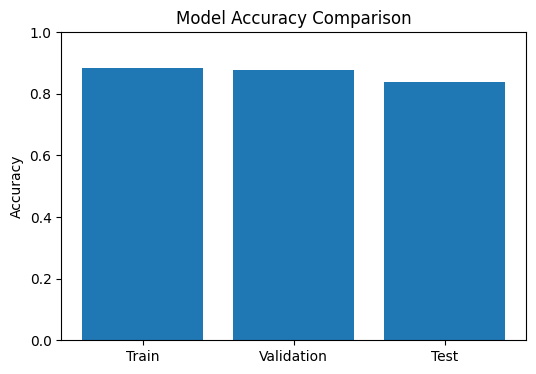

In [78]:
train_acc1 = history1.history['accuracy'][-1]
val_acc1 = history1.history['val_accuracy'][-1]
test_acc1 = metrics_dict1['compile_metrics']


plt.figure(figsize=(6,4))
plt.bar(['Train', 'Validation', 'Test'], 
        [train_acc1, val_acc1, test_acc1])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

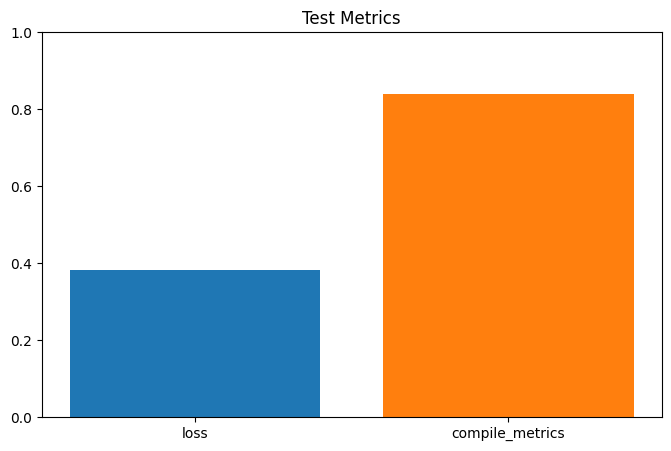

In [79]:
plt.figure(figsize=(8,5))

for metric1 in ['loss', 'compile_metrics']:
    plt.bar(metric1, metrics_dict1[metric1])

plt.title("Test Metrics")
plt.ylim(0,1)
plt.show()

In [80]:
print(history1.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


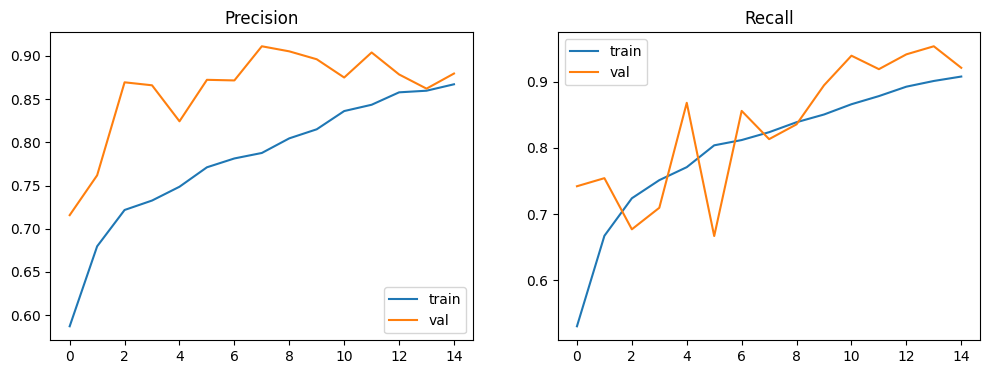

In [81]:
plt.figure(figsize=(12,4))

# Precision
plt.subplot(1,2,1)
plt.plot(history1.history['precision'], label='train')
plt.plot(history1.history['val_precision'], label='val')
plt.title("Precision")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history1.history['recall'], label='train')
plt.plot(history1.history['val_recall'], label='val')
plt.title("Recall")
plt.legend()

plt.show()

In [82]:
y_pred_prob1 = model1.predict(test_generator)
y_pred1 = (y_pred_prob1 > 0.5).astype("int32")

y_true1 = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step


In [83]:
print(classification_report(y_true1, y_pred1))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       238
           1       0.84      0.87      0.85       268

    accuracy                           0.84       506
   macro avg       0.84      0.84      0.84       506
weighted avg       0.84      0.84      0.84       506



In [84]:
precision1 = precision_score(y_true1, y_pred1)
recall1 = recall_score(y_true1, y_pred1)

f11 = 2 * (precision1 * recall1) / (precision1 + recall1 + 1e-8)

print("Precision:", precision1)
print("Recall:", recall1)
print("F1 Score:", f11)

Precision: 0.8351254480286738
Recall: 0.8694029850746269
F1 Score: 0.8519195562451666


In [85]:
y_train_pred_prob1 = model1.predict(train_generator)
y_train_pred1 = (y_train_pred_prob1 > 0.5).astype("int32")

y_train_true1 = train_generator.classes

289/289 ━━━━━━━━━━━━━━━━━━━━ 190s 657ms/step


In [86]:
y_test_pred_prob1 = model1.predict(test_generator)
y_test_pred1 = (y_test_pred_prob1 > 0.5).astype("int32")

y_test_true1 = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step


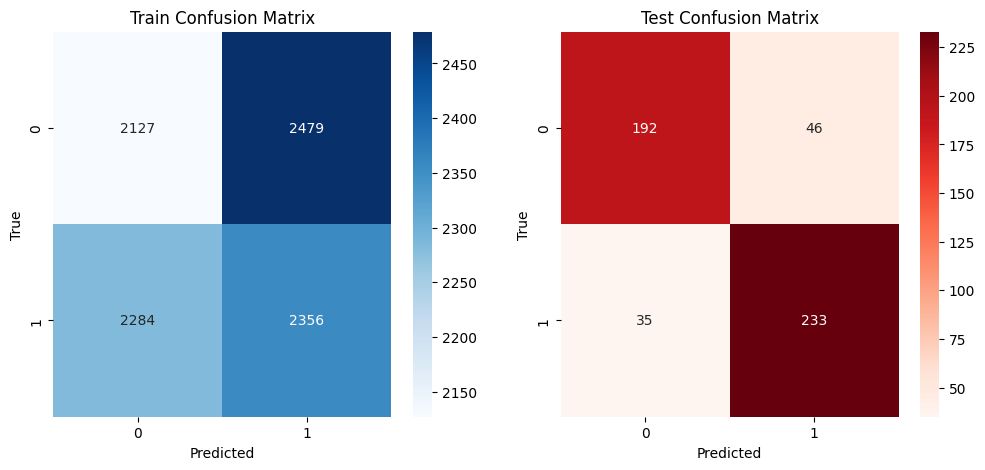

In [87]:
cm_train1 = confusion_matrix(y_train_true1, y_train_pred1)
cm_test1 = confusion_matrix(y_test_true1, y_test_pred1)

plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)
sns.heatmap(cm_train1, annot=True, fmt='d', cmap='Blues')
plt.title("Train Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# Test
plt.subplot(1,2,2)
sns.heatmap(cm_test1, annot=True, fmt='d', cmap='Reds')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

______________________________________________________________________________________________________________
💥 MODEL CNN + PSO
______________________________________________________________________________________________________________

In [ ]:
def build_model(lr, dropout_rate):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(128, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=AdamW(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

In [ ]:
def fitness_function(params):
    lr = params[0]
    dropout = params[1]

    model = build_model(lr, dropout)

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=3,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    return -val_acc 

In [ ]:
lb = [0.00001, 0.2]   # lower bounds
ub = [0.001, 0.5]     # upper bounds

best_params, best_score = pso(
    fitness_function,
    lb,
    ub,
    swarmsize=8,
    maxiter=5  
)

best_lr = best_params[0]
best_dropout = best_params[1]

print("Best LR:", best_lr)
print("Best Dropout:", best_dropout)

c:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Stopping search: maximum iterations reached --> 5
Best LR: 0.0006491785676972137
Best Dropout: 0.46729535198335437


In [16]:
model = build_model(best_lr, best_dropout)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

metrics_names = model.metrics_names
results = model.evaluate(test_generator)

metrics_dict = dict(zip(metrics_names, results))

for name, value in metrics_dict.items():
    print(f"{name}: {value}")

Epoch 1/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 316ms/step - accuracy: 0.5909 - loss: 0.6617 - precision: 0.5956 - recall: 0.5752 - val_accuracy: 0.6996 - val_loss: 0.6038 - val_precision: 0.8605 - val_recall: 0.5894
Epoch 2/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 317ms/step - accuracy: 0.7014 - loss: 0.5759 - precision: 0.6886 - recall: 0.7392 - val_accuracy: 0.6936 - val_loss: 0.6203 - val_precision: 0.8766 - val_recall: 0.5630
Epoch 3/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 91s 314ms/step - accuracy: 0.7626 - loss: 0.5032 - precision: 0.7385 - recall: 0.8157 - val_accuracy: 0.8142 - val_loss: 0.4398 - val_precision: 0.8492 - val_recall: 0.8354
Epoch 4/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 334ms/step - accuracy: 0.8046 - loss: 0.4322 - precision: 0.7762 - recall: 0.8580 - val_accuracy: 0.8432 - val_loss: 0.3769 - val_precision: 0.8244 - val_recall: 0.9350
Epoch 5/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 91s 315ms/step - accuracy: 0.8514 - loss: 0.3446 - precision: 0.8229 - recall: 0.8970 - val_accuracy: 0.8806

In [17]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


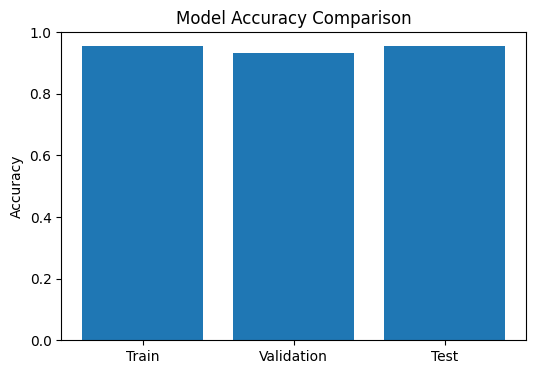

In [18]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
test_acc = metrics_dict['compile_metrics']


plt.figure(figsize=(6,4))
plt.bar(['Train', 'Validation', 'Test'], 
        [train_acc, val_acc, test_acc])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

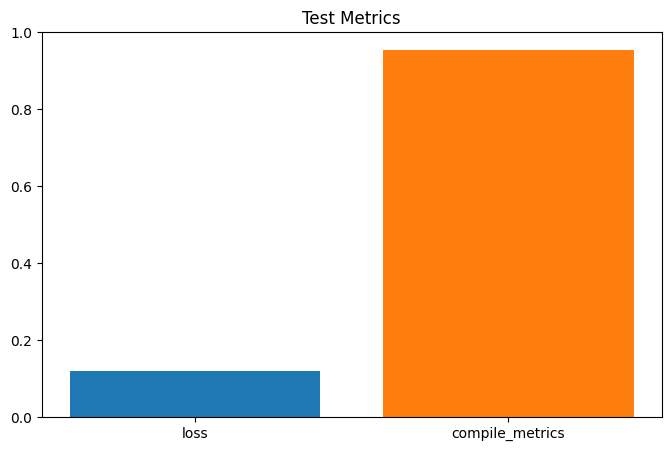

In [19]:
plt.figure(figsize=(8,5))

for metric in ['loss', 'compile_metrics']:
    plt.bar(metric, metrics_dict[metric])

plt.title("Test Metrics")
plt.ylim(0,1)
plt.show()

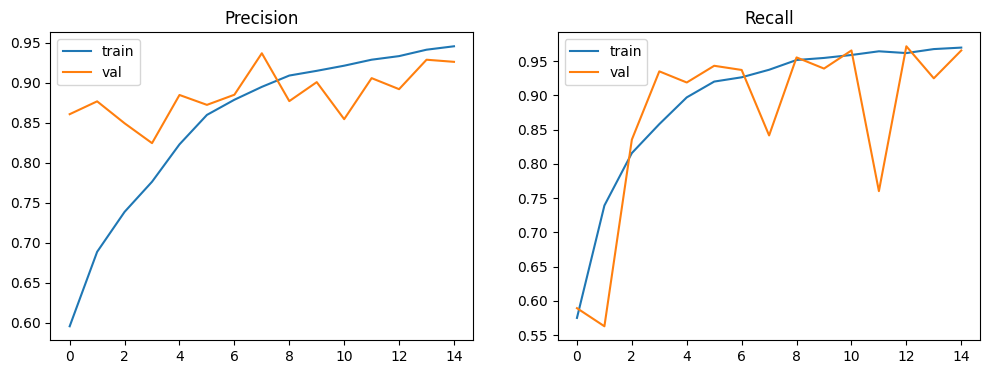

In [20]:
plt.figure(figsize=(12,4))

# Precision
plt.subplot(1,2,1)
plt.plot(history.history['precision'], label='train')
plt.plot(history.history['val_precision'], label='val')
plt.title("Precision")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history.history['recall'], label='train')
plt.plot(history.history['val_recall'], label='val')
plt.title("Recall")
plt.legend()

plt.show()

In [21]:
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype("int32")

y_true = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


In [22]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       238
           1       0.98      0.94      0.96       268

    accuracy                           0.95       506
   macro avg       0.95      0.96      0.95       506
weighted avg       0.96      0.95      0.95       506



In [23]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9766536964980544
Recall: 0.9365671641791045
F1 Score: 0.9561904711926713


In [24]:
y_train_pred_prob = model.predict(train_generator)
y_train_pred = (y_train_pred_prob > 0.5).astype("int32")

y_train_true = train_generator.classes

289/289 ━━━━━━━━━━━━━━━━━━━━ 63s 217ms/step


In [25]:
y_test_pred_prob = model.predict(test_generator)
y_test_pred = (y_test_pred_prob > 0.5).astype("int32")

y_test_true = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step


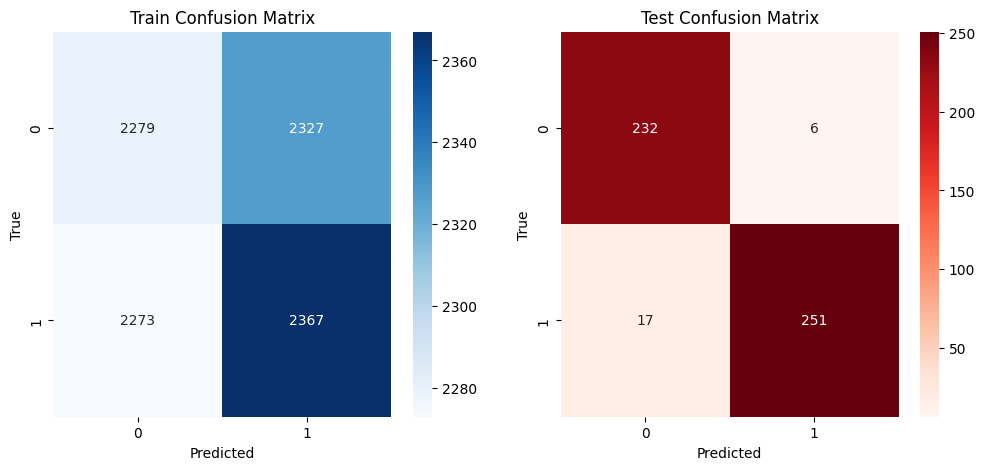

In [26]:
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Train Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# Test
plt.subplot(1,2,2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()